In [20]:
import os
import numpy as np
import lsst.meas.algorithms
from lsst.pipe.tasks.calibrateImage import CalibrateImageTask, CalibrateImageConfig
from lsst.pipe.tasks.calibrate import CalibrateTask
from lsst.pipe.tasks.characterizeImage import CharacterizeImageTask
from lsst.ap.association.utils import getRegion
from lsst.ip.isr import IsrTaskLSST
from lsst.daf.butler import Butler
import inspect

def isr(butler, dataId):
    raw = butler.get("raw", dataId=dataId)

    kwargs = dict(
        bias=butler.get("bias", dataId=dataId),
        dark=butler.get("dark", dataId=dataId),
        flat=butler.get("flat", dataId=dataId),
        ptc=butler.get("ptc", dataId=dataId),
        linearizer=butler.get("linearizer", dataId=dataId),
        crosstalk=butler.get("crosstalk", dataId=dataId),
        defects=butler.get("defects", dataId=dataId),
        camera=butler.get("camera", dataId=dataId),
    )

    # LSST-specific inputs
    try:
        kwargs["deferredChargeCalib"] = butler.get("cti", dataId=dataId)
    except Exception:
        pass

    try:
        kwargs["gainCorrection"] = butler.get("gain_correction", dataId=dataId)
    except Exception:
        pass

    for name in ("bfKernel", "bfk"):
        try:
            kwargs["bfKernel"] = butler.get(name, dataId=dataId)
            break
        except Exception:
            pass

    for name in ("electroBFDistortionMatrix", "electroBfDistortionMatrix"):
        try:
            kwargs["electroBfDistortionMatrix"] = butler.get(name, dataId=dataId)
            break
        except Exception:
            pass

    cfg = IsrTaskLSST.ConfigClass()
    cfg.ampOffset.doApplyAmpOffset = True
    task = IsrTaskLSST(config=cfg)

    allowed = set(inspect.signature(task.run).parameters.keys())
    kwargs = {k: v for k, v in kwargs.items() if k in allowed}

    res = task.run(raw, **kwargs)
    return res.exposure
    

def calibrate_old(butler, postISRCCD, dataId, threshold=5.0):
    char_config = CharacterizeImageTask.ConfigClass()
    char_config.doApCorr = True
    char_config.doDeblend = True
    #char_config.doApCorr = False
    #char_config.doDeblend = False
    char_task = CharacterizeImageTask(config=char_config)
    char_result = char_task.run(postISRCCD)

    calib_config = CalibrateTask.ConfigClass()
    calib_config.doAstrometry = False
    calib_config.doPhotoCal = False
    calib_task = CalibrateTask(config=calib_config, icSourceSchema=char_result.sourceCat.schema)
    calib_result = calib_task.run(postISRCCD, background=char_result.background, icSourceCat=char_result.sourceCat)
    return calib_result.outputExposure, calib_result.sourceCat


In [21]:
import os
import inspect
import lsst.meas.algorithms
from lsst.pipe.tasks.calibrateImage import CalibrateImageTask, CalibrateImageConfig
from lsst.ap.association.utils import getRegion
from lsst.ip.isr import IsrTaskLSST


def isr(butler, dataId):
    raw = butler.get("raw", dataId=dataId)

    kwargs = dict(
        bias=butler.get("bias", dataId=dataId),
        dark=butler.get("dark", dataId=dataId),
        flat=butler.get("flat", dataId=dataId),
        ptc=butler.get("ptc", dataId=dataId),
        linearizer=butler.get("linearizer", dataId=dataId),
        crosstalk=butler.get("crosstalk", dataId=dataId),
        defects=butler.get("defects", dataId=dataId),
        camera=butler.get("camera", dataId=dataId),
    )

    try:
        kwargs["deferredChargeCalib"] = butler.get("cti", dataId=dataId)
    except Exception:
        pass

    try:
        kwargs["gainCorrection"] = butler.get("gain_correction", dataId=dataId)
    except Exception:
        pass

    for name in ("bfKernel", "bfk"):
        try:
            kwargs["bfKernel"] = butler.get(name, dataId=dataId)
            break
        except Exception:
            pass

    for name in ("electroBFDistortionMatrix", "electroBfDistortionMatrix"):
        try:
            kwargs["electroBfDistortionMatrix"] = butler.get(name, dataId=dataId)
            break
        except Exception:
            pass

    cfg = IsrTaskLSST.ConfigClass()
    cfg.ampOffset.doApplyAmpOffset = True
    task = IsrTaskLSST(config=cfg)

    allowed = set(inspect.signature(task.run).parameters.keys())
    kwargs = {k: v for k, v in kwargs.items() if k in allowed}

    res = task.run(raw, **kwargs)
    return res.exposure


def calibrate(butler, postISRCCD, dataId, threshold=5.0):
    expanded = butler.registry.expandDataId(dataId)
    exposure_record = expanded.records["exposure"]

    cfg = CalibrateImageConfig()
    cfg.load(os.path.expandvars("$DRP_PIPE_DIR/config/calibrateImage.py"))

    cfg.connections.exposures = "post_isr_image"
    cfg.connections.stars_footprints = "single_visit_star_footprints"
    cfg.connections.psf_stars_footprints = "single_visit_psf_star_footprints"
    cfg.connections.psf_stars = "single_visit_psf_star"
    cfg.connections.initial_stars_schema = "single_visit_star_schema"
    cfg.connections.stars = "single_visit_star_unstandardized"
    cfg.connections.exposure = "preliminary_visit_image"
    cfg.connections.mask = "preliminary_visit_mask"
    cfg.connections.background = "preliminary_visit_image_background"

    cfg.useButlerCamera = True
    cfg.astrometry.matcher.maxOffsetPix = 800
    cfg.astrometry_ref_loader.pixelMargin = 800

    cfg.star_selector.name = "null"
    cfg.star_detection.thresholdValue = threshold

    cfg.connections.astrometry_ref_cat = "the_monster_20250219"
    cfg.connections.photometry_ref_cat = "the_monster_20250219"

    cfg.photometry_ref_loader.filterMap = {
        "u": "monster_ComCam_u",
        "g": "monster_ComCam_g",
        "r": "monster_ComCam_r",
        "i": "monster_ComCam_i",
        "z": "monster_ComCam_z",
        "y": "monster_ComCam_y",
    }
    cfg.photometry.applyColorTerms = False
    cfg.photometry.photoCatName = "the_monster_20250219"

    cfg.do_calibrate_pixels = False

    task = CalibrateImageTask(config=cfg)

    region = getRegion(postISRCCD)

    dt = butler.get_dataset_type("the_monster_20250219")
    dims = tuple(dt.dimensions.names)
    skypix_dim = [d for d in dims if d.startswith("htm") or d.startswith("healpix")][0]
    where = f"{skypix_dim}.region OVERLAPS :region"

    refs = list(
        butler.query_datasets(
            "the_monster_20250219",
            collections="refcats",
            where=where,
            bind={"region": region},
            find_first=False,
            with_dimension_records=True,
        )
    )
    if not refs:
        raise RuntimeError("No overlapping refcat shards found.")

    astrometry_loader = lsst.meas.algorithms.ReferenceObjectLoader(
        dataIds=[ref.dataId for ref in refs],
        refCats=[butler.getDeferred(ref) for ref in refs],
        name=cfg.connections.astrometry_ref_cat,
        config=cfg.astrometry_ref_loader,
        log=task.log,
    )
    task.astrometry.setRefObjLoader(astrometry_loader)

    photometry_loader = lsst.meas.algorithms.ReferenceObjectLoader(
        dataIds=[ref.dataId for ref in refs],
        refCats=[butler.getDeferred(ref) for ref in refs],
        name=cfg.connections.photometry_ref_cat,
        config=cfg.photometry_ref_loader,
        log=task.log,
    )
    task.photometry.match.setRefObjLoader(photometry_loader)

    result = task.run(
        exposures=[postISRCCD],
        id_generator=cfg.id_generator.apply(expanded),
        camera_model=butler.get("astrometry_camera", dataId=expanded),
        exposure_record=exposure_record,
        exposure_region=expanded.region,
    )
    return result.exposure, result.stars_footprints, result

In [13]:
repo = "dp2_prep"
collections = ["LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2", "refcats"]

butler = Butler(repo, collections=collections)

dataId1 = {"instrument": "LSSTCam", "exposure": 2025091900155, "visit": 2025091900155, "detector": 1, "band": "i",}
#dataId1 = {"instrument": "LSSTCam", "exposure": 2025081600551, "visit": 2025081600551, "detector": 26, "band": "i",}

postISRCCD = isr(butler, dataId1)
calexp, catalog, result = calibrate(butler, postISRCCD, dataId1, threshold=3)
#butler_calexp = butler.get("preliminary_visit_image", dataId=dataId1)
#butler_catalog = butler.get("single_visit_star_footprints", dataId=dataId1)

In [25]:
from lsst.drp.tasks.single_frame_detect_and_measure import (
    SingleFrameDetectAndMeasureTask,
    SingleFrameDetectAndMeasureConfig,
)

def single_frame_detect_and_measure(exposure, input_background, release_id=0):
    cfg = SingleFrameDetectAndMeasureConfig()

    cfg.connections.exposure = "preliminary_visit_image"
    cfg.connections.input_background = "preliminary_visit_image_background"
    cfg.connections.sources = "single_visit_star_reprocessed_unstandardized"
    cfg.connections.sources_footprints = "single_visit_star_reprocessed_footprints"
    cfg.connections.background = "preliminary_visit_image_reprocessed_background"

    cfg.id_generator.release_id = release_id

    cfg.detection.thresholdValue = 5.0
    cfg.detection.includeThresholdMultiplier = 1.0
    cfg.detection.reEstimateBackground = True
    cfg.detection.doTempLocalBackground = True

    cfg.deblend.maxFootprintArea = -1

    task = SingleFrameDetectAndMeasureTask(config=cfg)
    result = task.run(exposure=exposure, input_background=input_background)
    return result

In [29]:
pre_sfm = single_frame_detect_and_measure(calexp, result.background)

In [32]:
len(pre_sfm.sources_footprints)

1393

In [20]:
print(type(result))
print(sorted([k for k in dir(result) if not k.startswith("_")]))

<class 'lsst.pipe.base.struct.Struct'>
['applied_photo_calib', 'astrometry_matches', 'background', 'background_to_photometric_ratio', 'copy', 'exposure', 'getDict', 'mask', 'mergeItems', 'photometry_matches', 'psf_stars', 'psf_stars_footprints', 'stars', 'stars_footprints']


## Injection

In [5]:
%load_ext autoreload
%autoreload 2

REPO_ROOT = "/sdf/data/rubin/user/mrakovci/Projects/Asteroid_detection_CNN"
DATASET_CREATION = f"{REPO_ROOT}/ADCNN/data/dataset_creation"
for p in [REPO_ROOT, DATASET_CREATION]:
    if p not in sys.path:
        sys.path.insert(0, p)
        
from ADCNN.data.dataset_creation.common import *
from ADCNN.data.dataset_creation.simulate_inject import *

def one_detector_injection(n_inject, trail_length, mag, beta, repo, coll, dimensions, source_type, ref_dataId, seed=None, debug=False, mag_mode="psf_mag", psf_template="image", detection_threshold=5.0):
    if seed is None:
        seed = np.random.randint(0,10000)
    butler = Butler(repo, collections=coll)
    ref = butler.registry.findDataset(source_type, dataId=ref_dataId)
    postISRCCD = isr(butler, format_dataId(ref.dataId))
    #calexp, pre_injection_Src = calibrate(butler, postISRCCD, format_dataId(ref.dataId), threshold=detection_threshold)
    calexp, pre_injection_Src = calibrate(butler, postISRCCD, format_dataId(ref.dataId), threshold=detection_threshold)
        #calexp = butler.get("preliminary_visit_image", dataId=ref.dataId)
        #pre_injection_Src = butler.get("single_visit_star_footprints", dataId=ref.dataId)
    forbidden = build_forbidden_mask(calexp, pre_injection_Src, dimensions)
    injection_catalog = generate_one_line(n_inject, trail_length, mag, beta, ref, dimensions, seed, calexp, mag_mode=mag_mode, psf_template=psf_template, forbidden_mask=forbidden)
    injected_calexp, post_injection_Src = calibrate(butler, inject(calexp, injection_catalog), format_dataId(ref.dataId), threshold=detection_threshold)
    mask = np.zeros((dimensions.y, dimensions.x), dtype=np.uint16)
    for i, row in enumerate(injection_catalog):
        psf_width = injected_calexp.psf.getLocalKernel(Point2D(row["x"], row["y"])).getWidth()
        mask = draw_one_line(mask, [row["x"], row["y"]], row["beta"], row["trail_length"], true_value=i + 1,
                                 line_thickness=int(psf_width/2))
    injection_catalog, matched_fp_mask = stack_hits_by_footprints(post_src=crossmatch_catalogs (pre_injection_Src, post_injection_Src),
                                                                       calexp_pre=calexp,
                                                                       calexp_post=injected_calexp,
                                                                       dimensions=dimensions,
                                                                       truth_id_mask=mask,
                                                                       injection_catalog=injection_catalog,
                                                                       overlap_minpix=1,
                                                                       overlap_frac=0.0,
                                                                       return_matched_fp_masks=debug)

    real_labels = footprints_to_label_mask(pre_injection_Src, dimensions, dtype=np.uint16)
    return calexp, pre_injection_Src, injected_calexp, post_injection_Src, mask.astype("bool"), real_labels, injection_catalog, forbidden

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
repo = "dp2_prep"
collections = ["LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2", "refcats"]

butler = Butler(repo, collections=collections)

dataId1 = {"instrument": "LSSTCam", "exposure": 2025091900155, "visit": 2025091900155, "detector": 1, "band": "i",}

dims = butler.get("preliminary_visit_image.dimensions", dataId=dataId1)
calexp = butler.get("preliminary_visit_image", dataId=dataId1)
maglim = calexp.info.getSummaryStats().magLim

In [7]:
calexp, pre_injection_Src, injected_calexp, post_injection_Src, mask, real_labels, injection_catalog, forbidden = one_detector_injection (n_inject=300, trail_length=[0, 0], mag=[maglim, maglim], beta=[0, 0], 
                                                                                                 repo = repo, coll = collections, dimensions = dims,
                                                                                                 source_type = "preliminary_visit_image", ref_dataId=dataId1, mag_mode="psf_mag")

In [8]:
injection_catalog["stack_detection"].sum()

np.int64(164)

In [9]:
len(post_injection_Src)

1336

In [10]:
len(pre_injection_Src)

1393

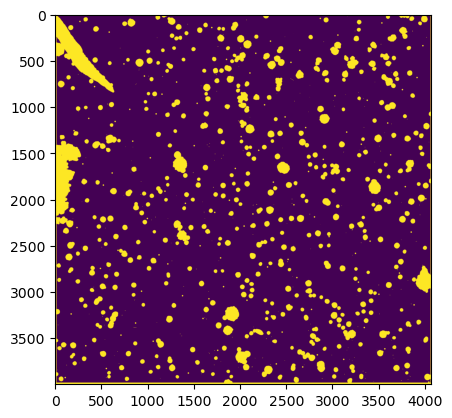

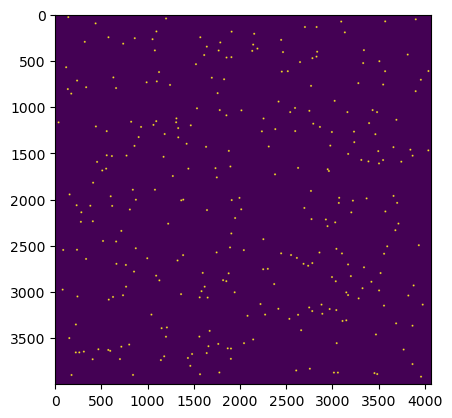

In [38]:
import matplotlib.pyplot as plt
plt.imshow(forbidden)
plt.show()
plt.imshow(mask)
plt.show()

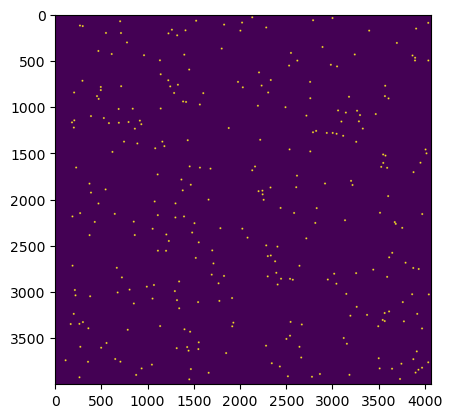

In [13]:
import matplotlib.pyplot as plt


In [11]:
len(pre_injection_Src), len(post_injection_Src), len(crossmatch_catalogs(pre_injection_Src, post_injection_Src))

(1393, 1336, 205)